# Universal Grammar Generative Model

## Setup stage

In [1]:
INSTALL = false

if INSTALL
    using Pkg
    Pkg.add("StatsPlots"); using StatsPlots
    Pkg.activate("psyc261")
    Pkg.add(["JLD2", "Distributions", "ProgressMeter", "Parameters", 
            "Random", "Gen", "Plots", "PyCall", "Conda", "JSON3"])
end

In [2]:
include("../src/ug_model.jl")
using .UGmodel

In [3]:
using Pkg
Pkg.activate("psyc261")
using JLD2
using Distributions
using ProgressMeter
using Parameters
using Random
using StatsPlots
using Gen, Plots
using PyCall
np = pyimport("numpy")

  Activating project at `~/Algorithms-of-the-Mind/aom/notebooks/psyc261`


PyObject <module 'numpy' from '/home/psyc2610_jdp69/.local/lib/python3.11/site-packages/numpy/__init__.py'>

## Generative Model

To start off, we extract the vocabulary from an external file and parse them into the grammatical categories that we established. In this case, they are nouns, transitive and intransitive verbs, adjectives and a Wh- word (what). After that, we create the fixed vocabulary used for inference.

In [4]:
const NOUNS = UGmodel.LEXICON.nouns
const VERBS_TRANS = UGmodel.LEXICON.verbs_trans
const VERBS_INTR = UGmodel.LEXICON.verbs_intr
const ADJECTIVES = UGmodel.LEXICON.adjectives
const WH_WORD = UGmodel.LEXICON.wh_word

"what"

In [5]:
# Creating fixed size vocabulary
const VOCAB = unique(vcat(["PAD", WH_WORD], NOUNS, VERBS_TRANS, VERBS_INTR, ADJECTIVES))
const VOCAB_SIZE = length(VOCAB)
const WORD_TO_IDX = Dict(w => i for (i,w) in enumerate(VOCAB))
const MAX_SENT_LEN = 6

6

### Emission probabilities and error

Derived from a HMM, this creates a noisy emission distribution given the specific grammatical category. This is our way of modeling imperfect language transmission.

In [6]:
function emission_probs(target_idx::Int; V::Int = VOCAB_SIZE, epsilon::Float64 = 0.05)
    @assert 0 < epsilon < 1
    probs = fill(epsilon / (V-1), V)
    probs[target_idx] = 1.0 -epsilon

    return probs

end

emission_probs (generic function with 1 method)

In [7]:
# Noise constant to account for misunderstandings, slip of the tongue etc.
# Generates ungrammatical sentences
const NOISE_PROB = 0.1

0.1

### Complete generative model

To model the Principles & Parameters prior, we are using the following UG parameters:

- Head directionality: in this case, we're using it to control whether the verb or the object will come first
- Subject drop: whether the subject of a sentence has to be kept explicit or if it can be dropped and understood from the context
- Adjective order: whether the noun or the adjective comes first
- Wh-fronting: in a Wh- question (what, who, which etc.), does the wh- word stay in its place (in-situ) or does it go to the front of the sentence

We then make the distinction for three different types of utterances: 
1. Transitive declarative: a phrase containing a subject, transitive verb, and its object in a declarative manner (no wh- word)
2. Intransitive: a phrase containing a subject and an intransitive verb
3. Transitive question: a phrase containing a subject, transitive verb, its object and a wh- word that can be fronted or not

We establish Bernoulli priors over each one of the parameters, and also a small chance that they might "slip" and occasionally be flipped in a given sentence. Although this is not the case for human languages, it suffices as a means to test our hypothesis.

The final sentence is then produced taking into account the noisy parameters and emission probability.

In [8]:
@gen function corpus_model(num_sentences::Int)
    # === Universal Grammar paramaters (theta) ===
    # Head direction: 1 = Verb-Object (VO), 0 = Object-Verb(OV)
    hd = @trace(bernoulli(0.5), :head_direction)

    # Subject drop: 1 = subject may be dropped, 0 = subject always present
    sd = @trace(bernoulli(0.5), :subject_drop)

    # Adjective order: 1 = Adjective-Noun (AN), 0 = Noun-Adjective (NA)
    ao = @trace(bernoulli(0.5), :adj_order)

    # Wh-fronting in question: 1 = wh-word at front, 0 = in-situ
    wh = @trace(bernoulli(0.5), :wh_fronting)
    
    sentences = Vector{Vector{String}}(undef, num_sentences)

    for i in 1:num_sentences
        # Utterance type: 1 = transitive declarative, 2 = intransitive, 3 = transitive question
        utt_type = @trace(categorical([0.4, 0.3, 0.3]), (:utt_type, i))

        # Sample lexical items
        subj_idx = @trace(categorical(fill(1/length(NOUNS), length(NOUNS))), (:subj, i))
        obj_idx = @trace(categorical(fill(1/length(NOUNS), length(NOUNS))), (:obj, i))
        adj_idx = @trace(categorical(fill(1/length(ADJECTIVES), length(ADJECTIVES))), (:adj, i))

        if utt_type == 1 || utt_type == 3
            v_idx = @trace(categorical(fill(1/length(VERBS_TRANS), length(VERBS_TRANS))), (:v_trans, i))
            verb = VERBS_TRANS[v_idx]
        else
            v_idx = @trace(categorical(fill(1/length(VERBS_INTR), length(VERBS_INTR))), (:v_intr, i))
            verb = VERBS_INTR[v_idx]
        end

        subj = NOUNS[subj_idx]
        obj = NOUNS[obj_idx]
        adj = ADJECTIVES[adj_idx]

        # Add adjective order error
        ao_slip = @trace(bernoulli(NOISE_PROB), (:ao_slip, i))
        effective_ao = ao_slip ? !ao : ao
        
        # Build NP for subject and object, respecting adjective order and taking error into account
        function make_np(noun::String, adj::String, order_rule::Bool)
            if order_rule == 1
                return [adj, noun] # Adj N
            else
                return [noun, adj] # N Adj
            end
        end

        subj_np = make_np(subj, adj, effective_ao)
        obj_np = make_np(obj, adj, effective_ao)

        # Add head direction error
        hd_slip = @trace(bernoulli(NOISE_PROB), (:hd_slip, i))
        effective_hd = hd_slip ? !hd : hd

        # Base clause word order for transitive
        vp = Vector{String}()
        if utt_type == 1 || utt_type == 3
            # Verb-Object vs. Object-Verb in the VP
            vp = (effective_hd == 1) ? vcat([verb], obj_np) : vcat(obj_np, [verb])
        else
            # Intransitive: just the verb
            vp = [verb]
        end

        # Add subject drop error
        sd_slip = @trace(bernoulli(NOISE_PROB), (:sd_slip, i))
        effective_sd = sd_slip ? !sd : sd

        # Drop subject if SD = 1
        drop_subj = (effective_sd == 1) ? @trace(bernoulli(0.5), (:drop_subj, i)) : 0

        clause = Vector{String}()

        if drop_subj == 0
            append!(clause, subj_np)
        end
        
        append!(clause, vp)

        # Handle questions
        if utt_type == 3
            wh_slip = @trace(bernoulli(NOISE_PROB), (:wh_slip, i))
            effective_wh = wh_slip ? !wh : wh
            
            if effective_wh == 1
                # wh-fronting
                clause = vcat([WH_WORD], clause)
            else
                # wh in-situ (append at the end)
                push!(clause, WH_WORD)
            end
        end

        sentences[i] = clause

        for pos in 1:MAX_SENT_LEN
            word = pos <= length(clause) ? clause[pos] : "PAD"
            vocab_idx = WORD_TO_IDX[word]
            probs = emission_probs(vocab_idx; V=VOCAB_SIZE, epsilon = NOISE_PROB * 0.5)
            @trace(categorical(probs), (:token, i, pos))
        end
    end

    return sentences
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Int64], false, Union{Nothing, Some{Any}}[nothing], var"##corpus_model#292", Bool[0], false)

We can generate a sample from our generative model. The trace contains the parameters used, and then the generated sentences.

In [9]:
trace = simulate(corpus_model, (10,))
sentences = get_retval(trace)
theta = (
    hd = trace[:head_direction],
    sd = trace[:subject_drop],
    ao = trace[:adj_order],
    wh = trace[:wh_fronting]
)
print(theta)
print(sentences)

(hd = false, sd = false, ao = false, wh = true)[["cat", "big", "sleep"], ["what", "fox", "big", "dog", "big", "see"], ["fox", "big", "fox", "big", "chase"], ["dog", "big", "see", "cat", "big"], ["what", "cat", "small", "dog", "small", "attack"], ["what", "big", "fox", "big", "dog", "chase"], ["what", "dog", "big", "dog", "big", "attack"], ["cat", "small", "fox", "small", "attack"], ["what", "fox", "small", "dog", "small", "attack"], ["what", "big", "cat", "big", "fox", "see"]]

## Neural Network

First, we establish a few constants for the architecture and training of the neural network. 

To push the NN in the direction of being a fast heuristic learner, we're only training it in 10 sentences in each language it sees.

We're using 128 neurons in the hidden layer to mimic the sort of structure used in a transformer NN (one-hot vector input - 128 hidden - 4 output). 

For training, we're running it for 500 epochs with 50 languages appearing in each epoch.

In [10]:
# Neural net params
const NUM_SENTS_TRAIN = 10
const INPUT_DIM = VOCAB_SIZE * MAX_SENT_LEN * NUM_SENTS_TRAIN
H = 128

NUM_EPOCHS = 500
EPOCH_SIZE = 50

TRAIN = false

const PARAMS_FILE = "innate_solver_params.jld2"

"innate_solver_params.jld2"

### Methods for saving NN

This is being used just to save the neural network weights rather than having to train it everytime, since it takes a while.

In [11]:
function save_nn_params(losses, filename=PARAMS_FILE)
    W1 = get_param(innate_solver, :W1)
    b1 = get_param(innate_solver, :b1)
    W2 = get_param(innate_solver, :W2)
    b2 = get_param(innate_solver, :b2)
    
    @save filename W1 b1 W2 b2 losses
    println("Parameters and training history saved to $filename")
end

function load_nn_params(filename=PARAMS_FILE)
    @load filename W1 b1 W2 b2 losses
    
    init_param!(innate_solver, :W1, W1)
    init_param!(innate_solver, :b1, b1)
    init_param!(innate_solver, :W2, W2)
    init_param!(innate_solver, :b2, b2)
    
    println("Parameters loaded from $filename")
    return losses
end

load_nn_params (generic function with 2 methods)

### Encoding the sentences

This function turns a vector of sentences into a one-hot encoded version of itself. Basically, it just turns the value to 1 if the given vocabulary word is present in that specific position. 

In [12]:
# Convert sentences into a flattened one hot encoded vector
function encode_corpus(sentences::Vector{Vector{String}})
    encoded = zeros(Float64, INPUT_DIM)

    cursor = 0
    for i in 1:NUM_SENTS_TRAIN
        if i > length(sentences) break end

        sent = sentences[i]
        for j in 1:MAX_SENT_LEN
            word = j <= length(sent) ? sent[j] : "PAD"

            vocab_idx = WORD_TO_IDX[word]

            encoded[cursor * VOCAB_SIZE + vocab_idx] = 1.0
            cursor += 1
        end
    end

    return encoded
end

encode_corpus (generic function with 1 method)

### Setting up constraints

This function sets up the constraints from a given theta.

In [13]:
function make_constraints(theta::NamedTuple)
    constraints = Gen.choicemap()
    constraints[:head_direction] = theta.hd
    constraints[:subject_drop] = theta.sd
    constraints[:adj_order] = theta.ao
    constraints[:wh_fronting] = theta.wh
    return constraints
end

make_constraints (generic function with 1 method)

This function sets up the constraints from a given a trace. It contains all random choices except the UG parameters as to not leak the data into the training set.

In [14]:
function make_obs_map(trace, n_sentences)
    obs_map = Gen.choicemap()
    
    for i in 1:n_sentences
        obs_map[(:utt_type, i)] = trace[(:utt_type, i)]
        obs_map[(:subj, i)] = trace[(:subj, i)]
        obs_map[(:obj, i)] = trace[(:obj, i)]
        obs_map[(:adj, i)] = trace[(:adj, i)]
        
        if trace[(:utt_type, i)] in [1, 3]
            obs_map[(:v_trans, i)] = trace[(:v_trans, i)]
        else
            obs_map[(:v_intr, i)] = trace[(:v_intr, i)]
        end
        
        for j in 1:MAX_SENT_LEN
            obs_map[(:token, i, j)] = trace[(:token, i, j)]
        end
    end
    
    return obs_map
end   

make_obs_map (generic function with 1 method)

In [15]:
function make_token_obs_upto(trace, up_to_sentence::Int)
    obs = Gen.choicemap()
    for i in 1:up_to_sentence
        for j in 1:MAX_SENT_LEN
            obs[(:token, i, j)] = trace[(:token, i, j)]
        end
    end
    return obs
end

make_token_obs_upto (generic function with 1 method)

In [16]:
function make_token_obs_for_sentence(trace, sentence_idx::Int)
    obs = Gen.choicemap()
    for j in 1:MAX_SENT_LEN
        obs[(:token, sentence_idx, j)] = trace[(:token, sentence_idx, j)]
    end
    return obs
end

make_token_obs_for_sentence (generic function with 1 method)

### Creating the innate solver neural network (Variational Approximation)

For the actual neural network, we're using an architecture that has only one hidden layer using the hyperbolic tangent as the activation function. The number of hidden neurons is set by the hyperparameters that we set earlier (128), and the output is a 4-element vector with the values of either 1 or 0 corresponding to the parameters of the language.

In [17]:
σ(x) = tanh.(x)
sigmoid(x) = 1.0 ./ (1.0 .+ exp.(-x))

@gen function innate_solver(input_vector::Vector{Float64})
    @param W1::Matrix{Float64}
    @param b1::Vector{Float64}
    @param W2::Matrix{Float64}
    @param b2::Vector{Float64}

    hidden_layer = σ(W1 * input_vector + b1)
    output = W2 * hidden_layer + b2

    probs = sigmoid(output)

    for i in 1:4
        @trace(Gen.bernoulli(probs[i]), (:param, i))
    end
    
    return probs
end

init_weight(out, inc) = randn(out, inc) * 0.01
init_param!(innate_solver, :W1, init_weight(H, INPUT_DIM))
init_param!(innate_solver, :b1, zeros(H))
init_param!(innate_solver, :W2, init_weight(4, H))
init_param!(innate_solver, :b2, zeros(4))

4-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0

### Generating synthetic languages from the GM

We're doing supervised learning as the method to train the neural network. The following function is used to generate the key-value pairs from languages generated using the generative model.

In [18]:
function supervised_training_batch_generator()
    tr = simulate(corpus_model, (NUM_SENTS_TRAIN,))
    sentences = get_retval(tr)

    input_vec = encode_corpus(sentences)

    constraints = Gen.choicemap()
    constraints[(:param, 1)] = tr[:head_direction]
    constraints[(:param, 2)] = tr[:subject_drop]
    constraints[(:param, 3)] = tr[:adj_order]
    constraints[(:param, 4)] = tr[:wh_fronting]

    return ((input_vec,), constraints)
end

supervised_training_batch_generator (generic function with 1 method)

### Training the innate solver

This cell then either trains the neural network using supervised learning with gradient descent or loads a pre-saved version of the weights to be used in the rest of the notebook. 

Parameters loaded from innate_solver_params.jld2
Skipped training, loading saved parameters...

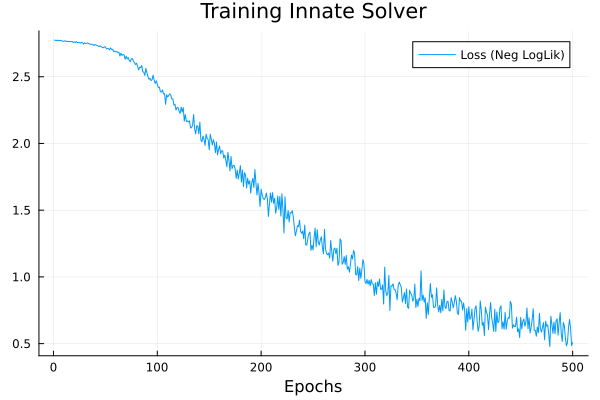

In [19]:
if TRAIN
    param_update = Gen.ParamUpdate(Gen.FixedStepGradientDescent(0.001), innate_solver)
    
    losses = Float64[]

    println("Training innate solver...")
    for epoch in 1:NUM_EPOCHS
        epoch_loss = 0.0
        
        for i in 1:EPOCH_SIZE
            (args, constraints) = supervised_training_batch_generator()
            (trace, weight) = generate(innate_solver, args, constraints)
            
            Gen.accumulate_param_gradients!(trace)
            
            epoch_loss += -get_score(trace)
        end
        
        Gen.apply!(param_update)
        
        avg_loss = epoch_loss / EPOCH_SIZE
        push!(losses, avg_loss)
        
        if epoch == 1 || epoch % 10 == 0
            println("Epoch $epoch: avg loss = $(round(avg_loss, digits=4))")
        end
    end

    save_nn_params(losses)

    display(plot(losses, label = "Loss (Neg LogLik)", xlabel = "Epochs", title = "Training Innate Solver"))

elseif isfile(PARAMS_FILE)
    losses = load_nn_params()

    print("Skipped training, loading saved parameters...")

    display(plot(losses, label = "Loss (Neg LogLik)", xlabel = "Epochs", title = "Training Innate Solver"))
else
    error("Nothing found, set TRAIN=true to train the model first")
end

# Results Visualization

In [20]:
logsumexp(x::Vector{Float64}) = maximum(x) + log(sum(exp.(x .- maximum(x))))

logsumexp (generic function with 1 method)

In [21]:
function effective_sample_size(log_weights::Vector{Float64})
    log_sum_w = logsumexp(log_weights)
    log_sum_w2 = logsumexp(2.0 .* log_weights)
    return exp(2.0 * log_sum_w - log_sum_w2)
end

effective_sample_size (generic function with 1 method)

In [22]:
function generate_problem(theta::NamedTuple; n_sentences=NUM_SENTS_TRAIN)
    trace, _ = generate(corpus_model, (n_sentences,), make_constraints(theta))
    return (
        theta = theta,
        sentences = get_retval(trace),
        input_vec = encode_corpus(get_retval(trace)),
        obs_map = make_obs_map(trace, n_sentences)
    )
end

generate_problem (generic function with 1 method)

In [23]:
function run_mcmc(obs_map, n_steps, init_params=nothing; n_sentences=NUM_SENTS_TRAIN)
    init_map = deepcopy(obs_map)
    if init_params !== nothing
        init_map[:head_direction] = init_params.hd
        init_map[:subject_drop] = init_params.sd
        init_map[:adj_order] = init_params.ao
        init_map[:wh_fronting] = init_params.wh
    end
    
    trace, _ = generate(corpus_model, (n_sentences,), init_map)
    history = Dict(:hd => Bool[], :sd => Bool[], :ao => Bool[], :wh => Bool[])
    
    for step in 0:n_steps
        push!(history[:hd], trace[:head_direction])
        push!(history[:sd], trace[:subject_drop])
        push!(history[:ao], trace[:adj_order])
        push!(history[:wh], trace[:wh_fronting])
        step < n_steps && (trace = mh_step(trace))
    end
    return history
end

run_mcmc (generic function with 2 methods)

In [24]:
function predict_nn(input_vec::Vector{Float64})
    W1 = get_param(innate_solver, :W1)
    b1 = get_param(innate_solver, :b1)
    W2 = get_param(innate_solver, :W2)
    b2 = get_param(innate_solver, :b2)

    hidden = σ(W1 * input_vec + b1)
    output = W2 * hidden + b2
    probs = sigmoid(output)

    preds = (
        hd = probs[1] > 0.5,
        sd = probs[2] > 0.5,
        ao = probs[3] > 0.5,
        wh = probs[4] > 0.5,
    )

    return preds, probs
end

predict_nn (generic function with 1 method)

In [25]:
# MH update on the 4 parameters
function mh_step(tr)
    tr, _ = mh(tr, select(:head_direction))
    tr, _ = mh(tr, select(:subject_drop))
    tr, _ = mh(tr, select(:adj_order))
    tr, _ = mh(tr, select(:wh_fronting))
    return tr
end

mh_step (generic function with 1 method)

In [26]:
function compute_convergence(history, target::NamedTuple)
    n = length(history[:hd])
    correct = [history[:hd][i] == target.hd && history[:sd][i] == target.sd &&
               history[:ao][i] == target.ao && history[:wh][i] == target.wh for i in 1:n]
    
    first_correct = findfirst(correct)
    conv_step = first_correct === nothing ? n : first_correct
    
    hamming = [4 - sum([history[:hd][i] == target.hd, history[:sd][i] == target.sd,
                        history[:ao][i] == target.ao, history[:wh][i] == target.wh]) for i in 1:n]
    
    window = 20
    moving_avg = [mean(correct[max(1, i-window+1):i]) for i in 1:n]
    
    return (correct=correct, convergence_step=conv_step, hamming=hamming, moving_avg=moving_avg)
end

compute_convergence (generic function with 1 method)

In [27]:
function all_language_types()
    languages = NamedTuple[]
    for hd in [false, true]
        for sd in [false, true]
            for ao in [false, true]
                for wh in [false, true]
                    push!(languages, (hd=hd, sd=sd, ao=ao, wh=wh))
                end
            end
        end
    end
    return languages
end

all_language_types (generic function with 1 method)

In [28]:
function language_name(theta::NamedTuple)
    hd_str = theta.hd ? "VO" : "OV"
    sd_str = theta.sd ? "+Drop" : "-Drop"
    ao_str = theta.ao ? "AN" : "NA"
    wh_str = theta.wh ? "Wh-Front" : "Wh-Situ"
    return "$hd_str, $sd_str, $ao_str, $wh_str"
end

language_name (generic function with 1 method)

In [29]:
@gen function nn_proposal(input_vec::Vector{Float64})
    _, nn_probs = predict_nn(input_vec)
    
    hd = @trace(bernoulli(nn_probs[1]), :head_direction)
    sd = @trace(bernoulli(nn_probs[2]), :subject_drop)
    ao = @trace(bernoulli(nn_probs[3]), :adj_order)
    wh = @trace(bernoulli(nn_probs[4]), :wh_fronting)
    
    return (hd=hd, sd=sd, ao=ao, wh=wh)
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Vector{Float64}], false, Union{Nothing, Some{Any}}[nothing], var"##nn_proposal#295", Bool[0], false)

In [30]:
function run_smc(
    trace,
    n_sentences::Int;
    n_particles::Int = 100,
    ess_threshold::Float64 = 0.5,
    use_nn_init::Bool = false,
    input_vec::Union{Vector{Float64}, Nothing} = nothing
)
    # Get observations for first sentence
    init_obs = make_token_obs_upto(trace, 1)
    
    # Initialize particle filter
    if use_nn_init && input_vec !== nothing
        # Use NN as proposal for initial particles
        state = Gen.initialize_particle_filter(
            corpus_model,
            (1,),  # Start with 1 sentence
            init_obs,
            nn_proposal,
            (input_vec,),
            n_particles
        )
    else
        # Use default (prior) proposal
        state = Gen.initialize_particle_filter(
            corpus_model,
            (1,),
            init_obs,
            n_particles
        )
    end
    
    # History tracking
    history = Dict(
        :map_estimate => NamedTuple[],
        :posterior_probs => Vector{Float64}[],  # P(theta) for all 16 thetas
        :ess => Float64[],
        :resampled => Bool[]
    )
    
    # Record initial state
    record_state!(history, state)
    
    # Process remaining sentences
    for t in 2:n_sentences
        # Get new observations for sentence t
        new_obs = make_token_obs_for_sentence(trace, t)
        
        # Update particles with new observation
        # Args: (num_sentences,) increases by 1 each step
        Gen.particle_filter_step!(
            state,
            (t,),                           # New args: now t sentences
            (UnknownChange(),),             # Argdiff: we don't track detailed changes
            new_obs                         # New observations
        )
        
        # Maybe resample based on ESS
        did_resample = Gen.maybe_resample!(
            state, 
            ess_threshold=ess_threshold * n_particles
        )
        push!(history[:resampled], did_resample)
        
        # Record state
        record_state!(history, state)
    end
    
    return history
end

run_smc (generic function with 1 method)

In [31]:
function record_state!(history, state::Gen.ParticleFilterState)
    traces = Gen.get_traces(state)
    log_weights = Gen.get_log_weights(state)
    
    # Normalize weights
    log_Z = logsumexp(log_weights)
    weights = exp.(log_weights .- log_Z)
    
    # Compute posterior over unique thetas
    all_thetas = all_language_types()
    theta_probs = zeros(16)
    
    for (tr, w) in zip(traces, weights)
        theta = (
            hd = tr[:head_direction],
            sd = tr[:subject_drop],
            ao = tr[:adj_order],
            wh = tr[:wh_fronting]
        )
        idx = findfirst(t -> t == theta, all_thetas)
        theta_probs[idx] += w
    end
    
    push!(history[:posterior_probs], theta_probs)
    
    # MAP estimate
    map_idx = argmax(theta_probs)
    push!(history[:map_estimate], all_thetas[map_idx])
    
    # ESS (computed from log weights)
    push!(history[:ess], effective_sample_size(log_weights))
end

record_state! (generic function with 1 method)

In [32]:
function compute_smc_convergence(history, target::NamedTuple)
    map_estimates = history[:map_estimate]
    n = length(map_estimates)
    
    # Check correctness at each step
    correct = [est == target for est in map_estimates]
    
    # First step where MAP = target
    first_correct = findfirst(correct)
    conv_step = first_correct === nothing ? n : first_correct
    
    # Hamming distance over time
    hamming = [
        4 - sum([
            map_estimates[i].hd == target.hd,
            map_estimates[i].sd == target.sd,
            map_estimates[i].ao == target.ao,
            map_estimates[i].wh == target.wh
        ]) for i in 1:n
    ]
    
    # Posterior probability of true theta over time
    all_thetas = all_language_types()
    target_idx = findfirst(t -> t == target, all_thetas)
    target_prob_history = [probs[target_idx] for probs in history[:posterior_probs]]
    
    # Entropy over time
    entropy_history = [
        -sum(p > 0 ? p * log(p) : 0.0 for p in probs)
        for probs in history[:posterior_probs]
    ]
    
    return (
        convergence_step = conv_step,
        final_correct = correct[end],
        stayed_converged = first_correct !== nothing && all(correct[first_correct:end]),
        target_prob_history = target_prob_history,
        entropy_history = entropy_history,
        ess_history = history[:ess]
    )
end

compute_smc_convergence (generic function with 1 method)

In [33]:
function run_trial_smc(
    theta::NamedTuple; 
    n_sentences::Int = NUM_SENTS_TRAIN,
    n_particles::Int = 100
)
    trace, _ = generate(corpus_model, (n_sentences,), make_constraints(theta))
    sentences = get_retval(trace)
    input_vec = encode_corpus(sentences)
    
    naive_history = run_smc(trace, n_sentences; n_particles=n_particles, use_nn_init=false)
    guided_history = run_smc(trace, n_sentences; n_particles=n_particles, use_nn_init=true, input_vec=input_vec)
    
    naive_metrics = compute_smc_metrics(naive_history, theta, n_sentences)
    guided_metrics = compute_smc_metrics(guided_history, theta, n_sentences)
    
    nn_preds, nn_probs = predict_nn(input_vec)
    nn_correct = (nn_preds.hd == theta.hd && nn_preds.sd == theta.sd &&
                  nn_preds.ao == theta.ao && nn_preds.wh == theta.wh)
    
    return (
        naive_metrics = naive_metrics,
        guided_metrics = guided_metrics,
        nn_correct = nn_correct,
        nn_probs = nn_probs,
        nn_preds = nn_preds,
        theta = theta
    )
end

run_trial_smc (generic function with 1 method)

In [34]:
function compute_smc_metrics(history, target::NamedTuple, n_sentences::Int)
    map_estimates = history[:map_estimate]
    
    # Did it ever converge?
    correct = [est == target for est in map_estimates]
    ever_converged = any(correct)
    
    # First convergence (or nothing)
    first_correct = findfirst(correct)
    
    # Final accuracy
    final_correct = correct[end]
    
    # Posterior probability of target over time
    all_thetas = all_language_types()
    target_idx = findfirst(t -> t == target, all_thetas)
    target_prob_history = [probs[target_idx] for probs in history[:posterior_probs]]
    
    # Area under the learning curve (higher = faster learning)
    auc = sum(target_prob_history) / n_sentences
    
    # Sentences to reach 50% posterior on correct grammar
    idx_50 = findfirst(p -> p >= 0.5, target_prob_history)
    sentences_to_50 = idx_50 === nothing ? Inf : idx_50
    
    # Sentences to reach 90% posterior
    idx_90 = findfirst(p -> p >= 0.9, target_prob_history)
    sentences_to_90 = idx_90 === nothing ? Inf : idx_90
    
    return (
        ever_converged = ever_converged,
        first_correct = first_correct,
        final_correct = final_correct,
        final_target_prob = target_prob_history[end],
        target_prob_history = target_prob_history,
        auc = auc,
        sentences_to_50 = sentences_to_50,
        sentences_to_90 = sentences_to_90
    )
end

compute_smc_metrics (generic function with 1 method)

In [35]:
## Visualizing Generated Sentences

function visualize_sentences(sentences, theta; max_display=8)
    println("="^60)
    println("UG Parameters: $(language_name(theta))")
    println("  Head Direction: $(theta.hd ? "VO (Verb-Object)" : "OV (Object-Verb)")")
    println("  Subject Drop: $(theta.sd ? "Allowed" : "Required")")
    println("  Adjective Order: $(theta.ao ? "AN (Adj-Noun)" : "NA (Noun-Adj)")")
    println("  Wh-Fronting: $(theta.wh ? "Fronted" : "In-situ")")
    println("="^60)
    for (i, sent) in enumerate(sentences[1:min(length(sentences), max_display)])
        println("  $i. $(join(sent, " "))")
    end
end

for (theta, name) in [
    ((hd=true, sd=false, ao=true, wh=true), "English-like"),
    ((hd=false, sd=true, ao=false, wh=false), "Japanese-like"),
    ((hd=true, sd=true, ao=true, wh=true), "Spanish-like"),
    ((hd=false, sd=false, ao=true, wh=false), "German-like")
]
    println("\n### $name ###")
    problem = generate_problem(theta; n_sentences=5)
    visualize_sentences(problem.sentences, theta; max_display=5)
end


### English-like ###
UG Parameters: VO, -Drop, AN, Wh-Front
  Head Direction: VO (Verb-Object)
  Subject Drop: Required
  Adjective Order: AN (Adj-Noun)
  Wh-Fronting: Fronted
  1. what small dog see small cat
  2. what big dog see big dog
  3. small cat sleep
  4. dog small chase dog small
  5. small cat attack small fox

### Japanese-like ###
UG Parameters: OV, +Drop, NA, Wh-Situ
  Head Direction: OV (Object-Verb)
  Subject Drop: Allowed
  Adjective Order: NA (Noun-Adj)
  Wh-Fronting: In-situ
  1. what cat small cat small attack
  2. dog small fox small chase
  3. cat big chase what
  4. cat big see
  5. run

### Spanish-like ###
UG Parameters: VO, +Drop, AN, Wh-Front
  Head Direction: VO (Verb-Object)
  Subject Drop: Allowed
  Adjective Order: AN (Adj-Noun)
  Wh-Fronting: Fronted
  1. what small cat chase
  2. sleep
  3. small fox attack small cat
  4. attack small dog
  5. chase dog big

### German-like ###
UG Parameters: OV, -Drop, AN, Wh-Situ
  Head Direction: OV (Object-Verb)
 

In [36]:
function compute_nn_metrics(trials)
    # Per-parameter accuracy
    hd_acc = mean([t.nn_preds.hd == t.theta.hd for t in trials])
    sd_acc = mean([t.nn_preds.sd == t.theta.sd for t in trials])
    ao_acc = mean([t.nn_preds.ao == t.theta.ao for t in trials])
    wh_acc = mean([t.nn_preds.wh == t.theta.wh for t in trials])
    
    # Exact match
    exact_match = mean([t.nn_correct for t in trials])
    
    # Hamming accuracy
    hamming_acc = mean([
        sum([
            t.nn_preds.hd == t.theta.hd,
            t.nn_preds.sd == t.theta.sd,
            t.nn_preds.ao == t.theta.ao,
            t.nn_preds.wh == t.theta.wh
        ]) / 4.0
        for t in trials
    ])
    
    return (
        per_param = (hd=hd_acc, sd=sd_acc, ao=ao_acc, wh=wh_acc),
        mean_param = mean([hd_acc, sd_acc, ao_acc, wh_acc]),
        exact_match = exact_match,
        hamming = hamming_acc
    )
end

compute_nn_metrics (generic function with 1 method)

In [37]:
function create_smc_summary_dashboard(all_trials)
    n_trials = length(all_trials)
    n_sentences = length(all_trials[1].naive_metrics.target_prob_history)
    
    # Aggregate metrics
    naive_converged = mean([t.naive_metrics.ever_converged for t in all_trials])
    guided_converged = mean([t.guided_metrics.ever_converged for t in all_trials])
    
    naive_final_prob = mean([t.naive_metrics.final_target_prob for t in all_trials])
    guided_final_prob = mean([t.guided_metrics.final_target_prob for t in all_trials])
    
    naive_auc = mean([t.naive_metrics.auc for t in all_trials])
    guided_auc = mean([t.guided_metrics.auc for t in all_trials])
    
    # Learning curves
    naive_curves = [t.naive_metrics.target_prob_history for t in all_trials]
    guided_curves = [t.guided_metrics.target_prob_history for t in all_trials]
    avg_naive = [mean([c[i] for c in naive_curves]) for i in 1:n_sentences]
    avg_guided = [mean([c[i] for c in guided_curves]) for i in 1:n_sentences]
    
    # Survival curves: fraction that reached 50% by each step
    function survival_curve(trials, threshold=0.5)
        n_sent = length(trials[1].naive_metrics.target_prob_history)
        [mean([any(t.naive_metrics.target_prob_history[1:i] .>= threshold) for t in trials]) for i in 1:n_sent]
    end
    naive_survival = [mean([t.naive_metrics.sentences_to_50 <= i for t in all_trials]) for i in 1:n_sentences]
    guided_survival = [mean([t.guided_metrics.sentences_to_50 <= i for t in all_trials]) for i in 1:n_sentences]
    
    # NN metrics
    nn_metrics = compute_nn_metrics(all_trials)
    
    # Create dashboard
    p = plot(layout=@layout([a b; c d]), size=(1200, 800),
             plot_title="Universal Grammar Learning: SMC Summary")
    
    # Panel 1: Average learning curves
    plot!(p[1], 1:n_sentences, avg_naive, label="Naive SMC", 
          linewidth=3, color=:indianred, ribbon=std.([[c[i] for c in naive_curves] for i in 1:n_sentences])/sqrt(n_trials), fillalpha=0.2)
    plot!(p[1], 1:n_sentences, avg_guided, label="NN-Guided SMC", 
          linewidth=3, color=:steelblue, ribbon=std.([[c[i] for c in guided_curves] for i in 1:n_sentences])/sqrt(n_trials), fillalpha=0.2)
    plot!(p[1], xlabel="Sentences observed", ylabel="P(correct grammar)",
          title="Learning Curves (± SE)", legend=:bottomright)
    
    # Panel 2: Survival curves (fraction reached 50% confidence)
    plot!(p[2], 1:n_sentences, naive_survival, label="Naive SMC",
          linewidth=3, color=:indianred)
    plot!(p[2], 1:n_sentences, guided_survival, label="NN-Guided SMC",
          linewidth=3, color=:steelblue)
    plot!(p[2], xlabel="Sentences observed", ylabel="Fraction reached 50% confidence",
          title="Cumulative Convergence", legend=:bottomright)
    hline!(p[2], [0.5, 1.0], linestyle=:dash, color=:gray, alpha=0.5, label="")
    
    # Panel 3: NN Per-parameter accuracy
    param_labels = ["Head\nDir", "Subj\nDrop", "Adj\nOrder", "Wh-\nFront"]
    param_accs = [nn_metrics.per_param.hd, nn_metrics.per_param.sd, 
                  nn_metrics.per_param.ao, nn_metrics.per_param.wh]
    bar!(p[3], param_labels, param_accs, title="NN Per-Parameter Accuracy",
         ylabel="Accuracy", legend=false, color=:steelblue, fillalpha=0.7, ylim=(0,1.1))
    hline!(p[3], [0.5], linestyle=:dash, color=:gray, linewidth=2)
    
    # Panel 4: Summary statistics
    plot!(p[4], axis=false, grid=false, ticks=false, xlim=(0,1), ylim=(0,1))
    
    annotate!(p[4], 0.5, 0.95, text("KEY METRICS", :center, 14, :bold))
    annotate!(p[4], 0.5, 0.88, text("─"^50, :center, 10))
    
    annotate!(p[4], 0.3, 0.78, text("Naive SMC", :center, 12))
    annotate!(p[4], 0.7, 0.78, text("NN-Guided SMC", :center, 12))
    
    annotate!(p[4], 0.3, 0.68, text("Final P(correct): $(round(naive_final_prob*100, digits=1))%", :center, 10))
    annotate!(p[4], 0.7, 0.68, text("Final P(correct): $(round(guided_final_prob*100, digits=1))%", :center, 10))
    
    annotate!(p[4], 0.3, 0.58, text("Ever converged: $(round(naive_converged*100, digits=1))%", :center, 10))
    annotate!(p[4], 0.7, 0.58, text("Ever converged: $(round(guided_converged*100, digits=1))%", :center, 10))
    
    annotate!(p[4], 0.3, 0.48, text("AUC: $(round(naive_auc, digits=3))", :center, 10))
    annotate!(p[4], 0.7, 0.48, text("AUC: $(round(guided_auc, digits=3))", :center, 10))
    
    annotate!(p[4], 0.5, 0.35, text("─"^50, :center, 10))
    
    # Relative improvement
    auc_improvement = (guided_auc - naive_auc) / naive_auc * 100
    prob_improvement = (guided_final_prob - naive_final_prob) / max(naive_final_prob, 0.01) * 100
    
    annotate!(p[4], 0.5, 0.25, text("AUC Improvement: +$(round(auc_improvement, digits=1))%", :center, 11))
    annotate!(p[4], 0.5, 0.15, text("Final Prob Improvement: +$(round(prob_improvement, digits=1))%", :center, 11))
    annotate!(p[4], 0.5, 0.05, text("NN Exact Match: $(round(nn_metrics.exact_match*100, digits=1))% | Hamming: $(round(nn_metrics.hamming*100, digits=1))%", :center, 10))
    
    return p
end

create_smc_summary_dashboard (generic function with 1 method)

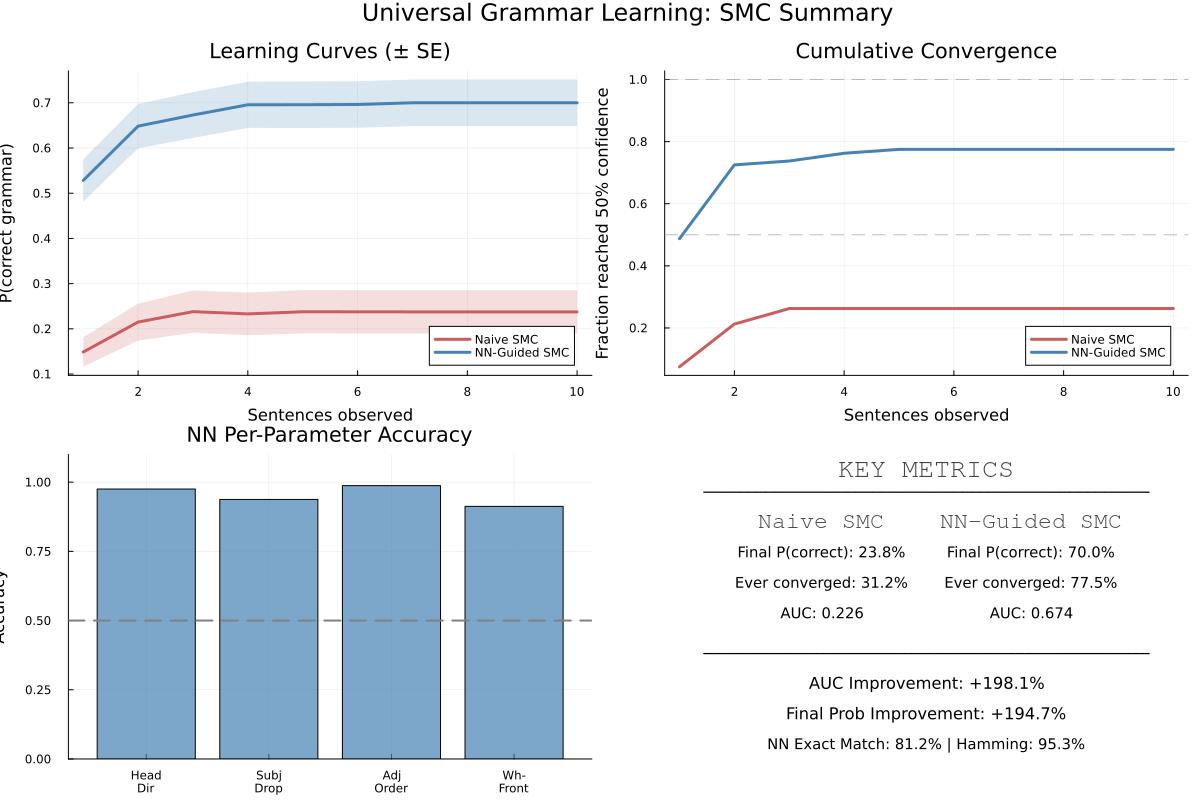

Per-param accuracy: (hd = 0.975, sd = 0.9375, ao = 0.9875, wh = 0.9125)
Exact match: 0.8125


GKS: could not find font bold.ttf


In [44]:
theta = (hd=true, sd=false, ao=true, wh=true)  # English-like
result = run_trial_smc(theta; n_sentences=10, n_particles=100)

# All trials
all_trials = []
for theta in all_language_types()
    for _ in 1:5
        push!(all_trials, run_trial_smc(theta; n_sentences=10, n_particles=100))
    end
end

# Dashboard
p = create_smc_summary_dashboard(all_trials)
display(p)

# NN metrics
nn_metrics = compute_nn_metrics(all_trials)
println("Per-param accuracy: ", nn_metrics.per_param)
println("Exact match: ", nn_metrics.exact_match)

In [39]:
# ## Parameter Space Exploration (Multiple Languages)

# # Select 4 representative languages to visualize
# DEMO_LANGUAGES = [
#     (hd=true, sd=false, ao=true, wh=true),   # English-like
#     (hd=false, sd=true, ao=false, wh=false), # Japanese-like  
#     (hd=false, sd=false, ao=true, wh=true),  # German-like
#     (hd=true, sd=true, ao=false, wh=false),  # Mixed type
# ]

# function get_trajectory(history)
#     n = length(history[:hd])
#     [(history[:hd][i], history[:sd][i], history[:ao][i], history[:wh][i]) for i in 1:n]
# end

# function traj_to_coords(traj, p1, p2; jitter=0.05)
#     ([Float64(t[p1]) + randn()*jitter for t in traj],
#      [Float64(t[p2]) + randn()*jitter for t in traj])
# end

# # Collect trajectories for all demo languages
# println("Generating trajectories for $(length(DEMO_LANGUAGES)) languages...")
# all_naive_trajs = []
# all_guided_trajs = []
# all_targets = []

# for theta in DEMO_LANGUAGES
#     problem = generate_problem(theta)
#     naive_hist = run_mcmc(problem.obs_map, 200)
#     guided_hist = run_mcmc(problem.obs_map, 200, predict_nn(problem.input_vec)[1])
    
#     push!(all_naive_trajs, get_trajectory(naive_hist))
#     push!(all_guided_trajs, get_trajectory(guided_hist))
#     push!(all_targets, (theta.hd, theta.sd, theta.ao, theta.wh))
# end

# # Color palette for different languages
# lang_colors = [:red, :orange, :purple, :brown]
# lang_names = ["English-like", "Japanese-like", "German-like", "Mixed"]

# param_pairs = [
#     (1, 2, "Head Dir", "Subj Drop"),
#     (1, 3, "Head Dir", "Adj Order"),
#     (1, 4, "Head Dir", "Wh-Front"),
#     (2, 3, "Subj Drop", "Adj Order"),
#     (2, 4, "Subj Drop", "Wh-Front"),
#     (3, 4, "Adj Order", "Wh-Front")
# ]

# p_space = plot(layout=(2, 3), size=(1500, 900), 
#                plot_title="Parameter Space Exploration (4 Languages)")

# for (i, (p1, p2, n1, n2)) in enumerate(param_pairs)
#     # Plot each language's trajectories
#     for (j, (naive_traj, guided_traj, target_vec)) in enumerate(zip(all_naive_trajs, all_guided_trajs, all_targets))
#         nx, ny = traj_to_coords(naive_traj, p1, p2)
#         gx, gy = traj_to_coords(guided_traj, p1, p2)
        
#         # Naive trajectory (faded)
#         plot!(p_space[i], nx, ny, 
#               label=(i==1 ? "Naive ($(lang_names[j]))" : ""),
#               color=lang_colors[j], alpha=0.2, linewidth=1,
#               xlabel=n1, ylabel=n2, xlim=(-0.3, 1.3), ylim=(-0.3, 1.3))
        
#         # Guided trajectory (solid)
#         plot!(p_space[i], gx, gy,
#               label=(i==1 ? "Guided ($(lang_names[j]))" : ""),
#               color=lang_colors[j], alpha=0.7, linewidth=2)
        
#         # Start points
#         scatter!(p_space[i], [nx[1]], [ny[1]], color=lang_colors[j], markersize=6, 
#                  markershape=:circle, alpha=0.3, label="")
#         scatter!(p_space[i], [gx[1]], [gy[1]], color=lang_colors[j], markersize=6, 
#                  markershape=:circle, label="")
        
#         # Target (star)
#         scatter!(p_space[i], [Float64(target_vec[p1])], [Float64(target_vec[p2])],
#                  color=lang_colors[j], markersize=10, markershape=:star5, 
#                  label=(i==1 ? "Target ($(lang_names[j]))" : ""))
#     end
# end

# display(p_space)

# # Summary statistics
# println("\nTrajectory Summary:")
# for (j, theta) in enumerate(DEMO_LANGUAGES)
#     naive_conv = findfirst(t -> t == all_targets[j], all_naive_trajs[j])
#     guided_conv = findfirst(t -> t == all_targets[j], all_guided_trajs[j])
#     naive_conv = naive_conv === nothing ? 201 : naive_conv
#     guided_conv = guided_conv === nothing ? 201 : guided_conv
#     println("  $(lang_names[j]): Naive=$(naive_conv) steps, Guided=$(guided_conv) steps")
# end

In [40]:
# ## Cross-Language Generalization

# function evaluate_all_languages(; n_trials=8, n_steps=200)
#     results = []
#     for (i, theta) in enumerate(all_language_types())
#         trials = [run_trial(theta; n_steps=n_steps) for _ in 1:n_trials]
#         push!(results, (
#             theta = theta,
#             name = language_name(theta),
#             naive_mean = mean([t.naive_conv for t in trials]),
#             guided_mean = mean([t.guided_conv for t in trials]),
#             speedup = mean([t.naive_conv for t in trials]) / max(mean([t.guided_conv for t in trials]), 1),
#             nn_accuracy = mean([t.nn_correct for t in trials])
#         ))
#         println("[$i/16] $(language_name(theta)): speedup=$(round(results[end].speedup, digits=1))x")
#     end
#     return results
# end

# println("Evaluating all 16 languages...")
# @time cross_results = evaluate_all_languages(n_trials=5, n_steps=200)

# # Heatmap visualization
# nn_acc_matrix, speedup_matrix = zeros(4,4), zeros(4,4)
# for r in cross_results
#     row = Int(r.theta.ao)*2 + Int(r.theta.wh) + 1
#     col = Int(r.theta.hd)*2 + Int(r.theta.sd) + 1
#     nn_acc_matrix[row, col] = r.nn_accuracy
#     speedup_matrix[row, col] = min(r.speedup, 200)
# end

# x_labels = ["OV-NoDrop", "OV-Drop", "VO-NoDrop", "VO-Drop"]
# y_labels = ["NA-InSitu", "NA-Front", "AN-InSitu", "AN-Front"]

# p_cross = plot(layout=(1,2), size=(1200,500))
# heatmap!(p_cross[1], x_labels, y_labels, nn_acc_matrix, title="NN Accuracy", color=:RdYlGn, clims=(0,1))
# heatmap!(p_cross[2], x_labels, y_labels, speedup_matrix, title="Speedup", color=:Blues)
# display(p_cross)

# println("\nMean NN accuracy: $(round(mean([r.nn_accuracy for r in cross_results])*100, digits=1))%")
# println("Mean speedup: $(round(mean([r.speedup for r in cross_results]), digits=1))x")

In [41]:
# ## Sample Efficiency Analysis (All Languages)

# function evaluate_sample_efficiency_all(; corpus_sizes=[2,5,10,15], n_trials_per_lang=3, n_steps=200)
#     results = Dict{Int, NamedTuple}()
    
#     for n_sents in corpus_sizes
#         println("Testing $n_sents sentences across all languages...")
#         naive_convs, guided_convs = Int[], Int[]
        
#         for theta in all_language_types()
#             for _ in 1:n_trials_per_lang
#                 trace, _ = generate(corpus_model, (n_sents,), make_constraints(theta))
#                 sents = get_retval(trace)
#                 obs_map = make_obs_map(trace, n_sents)
                
#                 # Pad sentences for NN input
#                 padded = [i <= length(sents) ? sents[i] : ["PAD"] for i in 1:NUM_SENTS_TRAIN]
#                 input_vec = encode_corpus(padded)
                
#                 # Naive
#                 naive_hist = run_mcmc(obs_map, n_steps; n_sentences=n_sents)
#                 push!(naive_convs, compute_convergence(naive_hist, theta).convergence_step)
                
#                 # Guided
#                 preds, _ = predict_nn(input_vec)
#                 guided_hist = run_mcmc(obs_map, n_steps, preds; n_sentences=n_sents)
#                 push!(guided_convs, compute_convergence(guided_hist, theta).convergence_step)
#             end
#         end
        
#         results[n_sents] = (naive_mean=mean(naive_convs), naive_std=std(naive_convs),
#                            guided_mean=mean(guided_convs), guided_std=std(guided_convs),
#                            speedup=mean(naive_convs)/max(mean(guided_convs),1))
#     end
#     return results
# end

# println("Running sample efficiency analysis (all languages)...")
# @time sample_results = evaluate_sample_efficiency_all(corpus_sizes=[2,5,10,15], n_trials_per_lang=2)

# # Visualization
# sizes = sort(collect(keys(sample_results)))
# p_eff = plot(sizes, [sample_results[k].naive_mean for k in sizes],
#              ribbon=[sample_results[k].naive_std for k in sizes], fillalpha=0.2,
#              label="Naive", color=:red, linewidth=3, marker=:circle,
#              title="Sample Efficiency (All 16 Languages)", xlabel="# Sentences", ylabel="Steps to Converge")
# plot!(p_eff, sizes, [sample_results[k].guided_mean for k in sizes],
#       ribbon=[sample_results[k].guided_std for k in sizes], fillalpha=0.2,
#       label="Guided", color=:blue, linewidth=3, marker=:square)
# display(p_eff)

# println("\nSpeedups by corpus size:")
# for k in sizes
#     println("  $k sentences: $(round(sample_results[k].speedup, digits=1))x")
# end

In [42]:
# ## Noise Sensitivity Analysis (All Languages)

# function evaluate_noise_sensitivity_all(; noise_levels=[0.0,0.05,0.1,0.15,0.2], n_trials_per_lang=2, n_steps=200)
#     results = Dict{Float64, NamedTuple}()
    
#     for noise in noise_levels
#         println("Testing noise=$noise across all languages...")
#         naive_convs, guided_convs = Int[], Int[]
        
#         for theta in all_language_types()
#             for _ in 1:n_trials_per_lang
#                 problem = generate_problem(theta)
                
#                 # Add noise to NN input
#                 noisy_input = clamp.(problem.input_vec .+ randn(length(problem.input_vec)) .* noise, 0.0, 1.0)
                
#                 # Naive
#                 naive_hist = run_mcmc(problem.obs_map, n_steps)
#                 push!(naive_convs, compute_convergence(naive_hist, theta).convergence_step)
                
#                 # Guided
#                 preds, _ = predict_nn(noisy_input)
#                 guided_hist = run_mcmc(problem.obs_map, n_steps, preds)
#                 push!(guided_convs, compute_convergence(guided_hist, theta).convergence_step)
#             end
#         end
        
#         results[noise] = (naive_mean=mean(naive_convs), guided_mean=mean(guided_convs),
#                          guided_std=std(guided_convs), speedup=mean(naive_convs)/max(mean(guided_convs),1))
#     end
#     return results
# end

# println("Running noise sensitivity analysis (all languages)...")
# @time noise_results = evaluate_noise_sensitivity_all()

# # Visualization
# levels = sort(collect(keys(noise_results)))
# p_noise = plot(layout=(1,2), size=(1100,400))
# plot!(p_noise[1], levels, [noise_results[k].guided_mean for k in levels],
#       ribbon=[noise_results[k].guided_std for k in levels], fillalpha=0.3,
#       title="Robustness to Noise (All Languages)", xlabel="Noise σ", ylabel="Steps to Converge",
#       label="Guided", color=:blue, linewidth=3, marker=:circle)
# plot!(p_noise[2], levels, [noise_results[k].speedup for k in levels],
#       title="Speedup vs Noise (All Languages)", xlabel="Noise σ", ylabel="Speedup",
#       label="Speedup", color=:purple, linewidth=3, marker=:diamond)
# display(p_noise)

In [43]:
# ## Summary Dashboard (Multi-Language)

# N_TRIALS_PER_LANG = 5
# N_STEPS = 500

# println("Running trials across ALL 16 languages...")
# all_trials = []
# for theta in all_language_types()
#     for _ in 1:N_TRIALS_PER_LANG
#         push!(all_trials, run_trial(theta; n_steps=N_STEPS))
#     end
# end
# println("Completed $(length(all_trials)) total trials")

# naive_convs = [t.naive_conv for t in all_trials]
# guided_convs = [t.guided_conv for t in all_trials]
# nn_accuracy = mean([t.nn_correct for t in all_trials])

# # For confidence display, average across all trials
# avg_probs = mean([collect(t.nn_probs) for t in all_trials])

# function create_summary_dashboard(naive_convs, guided_convs, avg_probs, nn_accuracy)
#     p = plot(layout=@layout([a b; c{0.3h} d{0.3h}]), size=(1400, 900),
#              plot_title="Universal Grammar Learning: Summary Dashboard (All 16 Languages)")
    
#     # Panel 1: Convergence Distribution
#     boxplot!(p[1], ["Naive\nLearner", "Guided\nLearner"], [naive_convs, guided_convs],
#              title="Convergence Speed (All Languages)", ylabel="MCMC Steps to Converge",
#              legend=false, color=[:indianred :steelblue], fillalpha=0.7)
#     scatter!(p[1], ones(length(naive_convs)) .+ randn(length(naive_convs)).*0.05,
#              naive_convs, color=:red, alpha=0.3, label="", markersize=3)
#     scatter!(p[1], 2 .* ones(length(guided_convs)) .+ randn(length(guided_convs)).*0.05,
#              guided_convs, color=:blue, alpha=0.3, label="", markersize=3)
    
#     # Panel 2: Speedup Distribution
#     speedups = naive_convs ./ max.(guided_convs, 1)
#     histogram!(p[2], speedups, title="Speedup Distribution (All Languages)",
#                xlabel="Speedup Factor", ylabel="Frequency",
#                color=:purple, alpha=0.7, legend=false, bins=20)
#     vline!(p[2], [mean(speedups)], color=:red, linewidth=3, linestyle=:dash)
#     vline!(p[2], [median(speedups)], color=:orange, linewidth=2, linestyle=:dot)
    
#     # Panel 3: Average NN Confidence
#     param_labels = ["Head\nDir", "Subj\nDrop", "Adj\nOrder", "Wh-\nFront"]
#     bar!(p[3], param_labels, avg_probs, title="Avg NN Confidence (All Languages)",
#          ylabel="P(param=1)", legend=false, color=:steelblue, fillalpha=0.7, ylim=(0,1.1))
#     hline!(p[3], [0.5], linestyle=:dash, color=:gray, linewidth=2)
    
#     # Panel 4: Key Metrics
#     plot!(p[4], axis=false, grid=false, ticks=false, xlim=(0,1), ylim=(0,1))
    
#     speedup_mean = round(mean(speedups), digits=1)
#     speedup_med = round(median(speedups), digits=1)
    
#     annotate!(p[4], 0.5, 0.90, text("KEY PERFORMANCE METRICS (16 Languages)", :center, 14))
#     annotate!(p[4], 0.5, 0.82, text("─"^45, :center, 10))
    
#     annotate!(p[4], 0.25, 0.68, text("Naive Learner", :left, 12))
#     annotate!(p[4], 0.30, 0.58, text("Mean: $(round(mean(naive_convs), digits=1)) steps", :left, 10))
#     annotate!(p[4], 0.30, 0.50, text("Std:  $(round(std(naive_convs), digits=1)) steps", :left, 10))
    
#     annotate!(p[4], 0.55, 0.68, text("Guided Learner", :left, 12))
#     annotate!(p[4], 0.60, 0.58, text("Mean: $(round(mean(guided_convs), digits=1)) steps", :left, 10))
#     annotate!(p[4], 0.60, 0.50, text("Std:  $(round(std(guided_convs), digits=1)) steps", :left, 10))
    
#     annotate!(p[4], 0.5, 0.35, text("─"^45, :center, 10))
#     annotate!(p[4], 0.5, 0.22, text("Speedup: $(speedup_mean)x (mean) / $(speedup_med)x (median)", :center, 11))
#     annotate!(p[4], 0.5, 0.12, text("NN Accuracy: $(round(nn_accuracy*100, digits=1))% across all languages", :center, 11))
    
#     return p
# end

# p_dashboard = create_summary_dashboard(naive_convs, guided_convs, avg_probs, nn_accuracy)
# display(p_dashboard)